# Hybrid Recommendation System using SVD

This notebook implements a hybrid recommendation system using Singular Value Decomposition (SVD), which combines collaborative filtering and content-based approaches for the educational content recommendation system.

## Objectives
1. Prepare user-item interaction matrix
2. Extract item features for content-based filtering
3. Implement collaborative filtering using SVD
4. Combine with content-based approach
5. Evaluate and tune the hybrid model

In [2]:
# Import required libraries
import os
import sys
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.feature_extraction.text import TfidfVectorizer

# Set up system path
sys.path.append(os.path.abspath(".."))

# Import custom modules
from src.recommender.hybrid import SVDHybridRecommender
from src.evaluation.metrics import tune_hybrid_weights

# For reproducibility
np.random.seed(42)

# Configure plotting aesthetics
sns.set_theme(style="whitegrid", palette="viridis")

## 1. Load and Prepare Data

In [3]:
# Load the datasets
lectures_data = pd.read_csv('../data/cleaned/cleaned_lectures.csv')
merged_data = pd.read_csv('../data/cleaned/merged_cleaned_data.csv')

# Display basic info about the datasets
print(f"Lectures dataset shape: {lectures_data.shape}")
print(f"Merged data shape: {merged_data.shape}")

Lectures dataset shape: (1021, 6)
Merged data shape: (117167, 14)


In [4]:
# Create subject categories based on ranges of tag values
# These mappings are based on TOEIC structure
def get_subject_category(tag):
    try:
        tag_val = float(tag)
        if 1 <= tag_val < 23:
            return "Listening Skills"
        elif 23 <= tag_val < 52:
            return "Reading Skills"
        elif 52 <= tag_val < 70:
            return "Speaking Skills"
        elif 70 <= tag_val < 150:
            return "Writing Skills"
        elif 150 <= tag_val < 200:
            return "Test Preparation"
        elif 200 <= tag_val < 300:
            return "Grammar & Vocabulary"
        else:
            return "General"
    except:
        return "General"

# Map part numbers to human-readable names
part_names = {
    0: "Introduction",
    1: "Listening Comprehension",
    2: "Reading Comprehension",
    3: "Grammar & Vocabulary",
    4: "Speaking Assessment",
    5: "Writing Exercises",
    6: "Practice Tests",
    7: "Additional Resources"
}

# Apply mappings
lectures_data['subject_category'] = lectures_data['tags'].apply(get_subject_category)
lectures_data['part_name'] = lectures_data['part'].map(part_names)

## 2. Create Bundle Features

Let's extract bundle information for content-based features in our hybrid model.

In [5]:
# Extract unique bundle information
bundle_info = merged_data.groupby('bundle_id').agg({
    'part': 'first',
    'tags': lambda x: ';'.join(set(str(i) for i in x if pd.notna(i))),
    'question_id': lambda x: len(set(x))  # Number of questions in bundle
}).reset_index()

# Rename columns for clarity
bundle_info.columns = ['bundle_id', 'part', 'tags', 'question_count']

# Map part to human-readable names
bundle_info['part_name'] = bundle_info['part'].map(part_names)

# Create subject category based on tags
bundle_info['subject_category'] = bundle_info['tags'].apply(get_subject_category)

# Calculate bundle popularity from interaction data
bundle_popularity = merged_data['bundle_id'].value_counts().reset_index()
bundle_popularity.columns = ['bundle_id', 'interaction_count']

# Calculate bundle difficulty from correct answer rates
bundle_difficulty = merged_data.groupby('bundle_id').apply(
    lambda x: (x['user_answer'] == x['correct_answer']).mean()
).reset_index()
bundle_difficulty.columns = ['bundle_id', 'success_rate']

# Merge all features
bundle_features = bundle_info.merge(bundle_popularity, on='bundle_id', how='left')
bundle_features = bundle_features.merge(bundle_difficulty, on='bundle_id', how='left')

# Fill missing values
bundle_features['interaction_count'] = bundle_features['interaction_count'].fillna(0)
bundle_features['success_rate'] = bundle_features['success_rate'].fillna(0.5)

print(f"Total unique bundles: {len(bundle_features)}")
bundle_features.head()

Total unique bundles: 8260


C:\Users\karat\AppData\Local\Temp\ipykernel_23956\3732587692.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bundle_difficulty = merged_data.groupby('bundle_id').apply(


,bundle_id,part,tags,question_count,part_name,subject_category,interaction_count,success_rate
0,b1,1,1;2;179;181,1,Listening Comprehension,General,6,0.833333
1,b10,1,17;7;182,1,Listening Comprehension,General,47,0.319149
2,b100,1,22;2;181,1,Listening Comprehension,General,7,1.000000
3,b1000,2,24;33;182;183,1,Reading Comprehension,General,46,0.760870
4,b1001,2,34;35;182;183,1,Reading Comprehension,General,12,0.583333


## 3. Create User-Item Interaction Matrix

In [6]:
# Filter users with minimum interactions for better model performance
min_interactions = 5
user_counts = merged_data['user_id'].value_counts()
valid_users = user_counts[user_counts >= min_interactions].index
filtered_data = merged_data[merged_data['user_id'].isin(valid_users)]

print(f"Original users: {merged_data['user_id'].nunique()}")
print(f"Filtered users with {min_interactions}+ interactions: {len(valid_users)}")
print(f"Retained {len(filtered_data) / len(merged_data):.2%} of interactions")

Original users: 999
Filtered users with 5+ interactions: 881
Retained 99.74% of interactions


In [7]:
# Create correctness as a measure of interaction quality
filtered_data = filtered_data.copy()  # Ensures modifications don't affect original data
filtered_data.loc[:, 'correct'] = (filtered_data['user_answer'] == filtered_data['correct_answer']).astype(int)

# Aggregate user-item interactions
user_item_data = filtered_data.groupby(['user_id', 'bundle_id']).agg(
    correctness_rate=('correct', 'mean'),
    interaction_count=('correct', 'count'),
    avg_time=('elapsed_time', 'mean'),
    part=('part', 'first'),
    tags=('tags', lambda x: ';'.join(set(str(i) for i in x)))
).reset_index()

# Create pivot table with interaction count as values
user_item_matrix = user_item_data.pivot_table(
    index='user_id', 
    columns='bundle_id', 
    values='interaction_count',
    fill_value=0
)

# Display user-item matrix characteristics
print(f"User-item matrix shape: {user_item_matrix.shape}")
print(f"Sparsity: {1 - (user_item_matrix > 0).sum().sum() / (user_item_matrix.shape[0] * user_item_matrix.shape[1]):.4f}")

User-item matrix shape: (881, 8256)
Sparsity: 0.9892


## 4. Create ID Mappings

In [8]:
# Create user and bundle ID mappings
user_ids = filtered_data['user_id'].unique()
bundle_ids = filtered_data['bundle_id'].unique()

# Create user mapping
user_map = {user_id: idx for idx, user_id in enumerate(np.unique(user_ids))}
reverse_user_map = {idx: user_id for user_id, idx in user_map.items()}

# Create item mapping
item_map = {bundle_id: idx for idx, bundle_id in enumerate(np.unique(bundle_ids))}
reverse_item_map = {idx: bundle_id for bundle_id, idx in item_map.items()}

print(f"Number of users: {len(user_map)}")
print(f"Number of items: {len(item_map)}")

Number of users: 881
Number of items: 8256


## 5. Prepare Content Features Matrix

In [9]:
# Create feature vectors for content-based part
n_items = len(item_map)

# Add difficulty category
bundle_features['difficulty_level'] = pd.cut(
    bundle_features['success_rate'], 
    bins=[0, 0.3, 0.7, 1.0], 
    labels=['Hard', 'Medium', 'Easy']
)

# One-hot encode features
part_dummies = pd.get_dummies(bundle_features['part'], prefix='part')
subject_dummies = pd.get_dummies(bundle_features['subject_category'], prefix='subject')
difficulty_dummies = pd.get_dummies(bundle_features['difficulty_level'], prefix='difficulty')

# Combine feature matrices
content_features = pd.concat([part_dummies, subject_dummies, difficulty_dummies], axis=1)

# Add bundle_id for mapping
content_features = pd.concat([bundle_features[['bundle_id']], content_features], axis=1)

# Create a matrix with internal indices
# feature_matrix = np.zeros((n_items, content_features.shape[1] - 1))
feature_matrix = np.zeros((n_items, content_features.drop(columns=['bundle_id']).shape[1]))

# Fill the feature matrix with values
for _, row in content_features.iterrows():
    bundle_id = row['bundle_id']
    if bundle_id in item_map:
        idx = item_map[bundle_id]
        feature_matrix[idx] = row.values[1:]

# Normalize features
feature_matrix = normalize(feature_matrix, axis=1, norm='l2')

# Compute content similarity
content_similarity = cosine_similarity(feature_matrix)

print(f"Content features matrix shape: {feature_matrix.shape}")

Content features matrix shape: (8256, 12)


## 6. Create Ratings Matrix for SVD

In [10]:
# Create ratings matrix for SVD
n_users = len(user_map)
n_items = len(item_map)
ratings_matrix = np.zeros((n_users, n_items))

# Fill with interaction values
for _, row in user_item_data.iterrows():
    user_id = row['user_id']
    bundle_id = row['bundle_id']
    
    if user_id in user_map and bundle_id in item_map:
        user_idx = user_map[user_id]
        item_idx = item_map[bundle_id]
        
        # Use interaction_count as the rating
        rating = row['interaction_count']
        
        # Additionally, boost rating if correctness rate is high
        if not pd.isna(row['correctness_rate']):
            # Scale correctness rate to a small boost (0.1-0.5)
            boost = 0.1 + (row['correctness_rate'] * 0.4)
            rating = rating * (1 + boost)
        
        ratings_matrix[user_idx, item_idx] = rating

# Calculate mean rating of non-zero entries
mean_rating = np.mean(ratings_matrix[ratings_matrix > 0])
print(f"Ratings matrix shape: {ratings_matrix.shape}")
print(f"Mean rating: {mean_rating:.4f}")

Ratings matrix shape: (881, 8256)
Mean rating: 2.0131


## 7. Train-Test Split for Evaluation

In [11]:
# Create a list of all non-zero entries in the ratings matrix
interactions = []
for u in range(n_users):
    for i in range(n_items):
        if ratings_matrix[u, i] > 0:
            interactions.append((u, i, ratings_matrix[u, i]))

# Split interactions into train and test sets
train_interactions, test_interactions = train_test_split(
    interactions, test_size=0.2, random_state=42
)

# Create train and test matrices
train_matrix = np.zeros_like(ratings_matrix)
test_matrix = np.zeros_like(ratings_matrix)

# Fill train matrix
for u, i, r in train_interactions:
    train_matrix[u, i] = r

# Fill test matrix
for u, i, r in test_interactions:
    test_matrix[u, i] = r

print(f"Total interactions: {len(interactions):,}")
print(f"Training set: {len(train_interactions):,} interactions")
print(f"Test set: {len(test_interactions):,} interactions")

Total interactions: 78,656
Training set: 62,924 interactions
Test set: 15,732 interactions


## 8. SVD Model Implementation

In [12]:
# Initialize and fit the model
svd_recommender = SVDHybridRecommender(n_factors=20, combine_weight=0.7)
svd_recommender.initialize(train_matrix, user_map, item_map, reverse_item_map)
svd_recommender.fit(train_matrix, content_similarity)

C:\Users\karat\AppData\Local\Temp\ipykernel_23956\3711866339.py:4: SparseEfficiencyWarning: Comparing a sparse matrix with 0 using == is inefficient, try using != instead.
  svd_recommender.fit(train_matrix, content_similarity)
c:\Users\karat\Downloads\Data-Driven-Personalized-Educational-Content-Recommendation-System\.venv\lib\site-packages\scipy\sparse\_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
INFO:src.recommender.hybrid:SVD model trained successfully with 20 factors
INFO:src.recommender.hybrid:User factors shape: (881, 20)
INFO:src.recommender.hybrid:Item factors shape: (8256, 20)


c:\Users\karat\Downloads\Data-Driven-Personalized-Educational-Content-Recommendation-System\src\evaluation\metrics.py:118: SparseEfficiencyWarning: Comparing a sparse matrix with 0 using == is inefficient, try using != instead.
  model.fit(train_matrix, content_sim)


Testing hybrid weight: 0.1


INFO:src.recommender.hybrid:SVD model trained successfully with 20 factors
INFO:src.recommender.hybrid:User factors shape: (881, 20)
INFO:src.recommender.hybrid:Item factors shape: (8256, 20)
INFO:src.recommender.hybrid:Generated 10 recommendations for user 2
INFO:src.recommender.hybrid:Generated 10 recommendations for user 3
INFO:src.recommender.hybrid:Generated 10 recommendations for user 4
INFO:src.recommender.hybrid:Generated 10 recommendations for user 5
INFO:src.recommender.hybrid:Generated 10 recommendations for user 6
INFO:src.recommender.hybrid:Generated 10 recommendations for user 7
INFO:src.recommender.hybrid:Generated 10 recommendations for user 8
INFO:src.recommender.hybrid:Generated 10 recommendations for user 9
INFO:src.recommender.hybrid:Generated 10 recommendations for user 10
INFO:src.recommender.hybrid:Generated 10 recommendations for user 11
INFO:src.recommender.hybrid:Generated 10 recommendations for user 12
INFO:src.recommender.hybrid:Generated 10 recommendations 

{'weight': np.float64(0.1), 'precision@10': 0.01796178343949043, 'recall@10': 0.00998061916605671, 'rmse': np.float64(2.530628659914266)}
Testing hybrid weight: 0.2


c:\Users\karat\Downloads\Data-Driven-Personalized-Educational-Content-Recommendation-System\.venv\lib\site-packages\scipy\sparse\_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
INFO:src.recommender.hybrid:SVD model trained successfully with 20 factors
INFO:src.recommender.hybrid:User factors shape: (881, 20)
INFO:src.recommender.hybrid:Item factors shape: (8256, 20)
INFO:src.recommender.hybrid:Generated 10 recommendations for user 2
INFO:src.recommender.hybrid:Generated 10 recommendations for user 3
INFO:src.recommender.hybrid:Generated 10 recommendations for user 4
INFO:src.recommender.hybrid:Generated 10 recommendations for user 5
INFO:src.recommender.hybrid:Generated 10 recommendations for user 6
INFO:src.recommender.hybrid:Generated 10 recommendations for user 7
INFO:src.recommender.hybrid:Generated 10 recommendations for user 8
INFO:src.recommender.hybrid:Generate

...

{'weight': np.float64(0.7), 'precision@10': 0.019363057324840748, 'recall@10': 0.01403879147868721, 'rmse': np.float64(2.530628659914266)}
Testing hybrid weight: 0.8


c:\Users\karat\Downloads\Data-Driven-Personalized-Educational-Content-Recommendation-System\.venv\lib\site-packages\scipy\sparse\_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
INFO:src.recommender.hybrid:SVD model trained successfully with 20 factors
INFO:src.recommender.hybrid:User factors shape: (881, 20)
INFO:src.recommender.hybrid:Item factors shape: (8256, 20)
INFO:src.recommender.hybrid:Generated 10 recommendations for user 2
INFO:src.recommender.hybrid:Generated 10 recommendations for user 3
INFO:src.recommender.hybrid:Generated 10 recommendations for user 4
INFO:src.recommender.hybrid:Generated 10 recommendations for user 5
INFO:src.recommender.hybrid:Generated 10 recommendations for user 6
INFO:src.recommender.hybrid:Generated 10 recommendations for user 7
INFO:src.recommender.hybrid:Generated 10 recommendations for user 8
INFO:src.recommender.hybrid:Generate

{'weight': np.float64(0.8), 'precision@10': 0.021146496815286613, 'recall@10': 0.01964395824939955, 'rmse': np.float64(2.530628659914266)}
Testing hybrid weight: 0.9


c:\Users\karat\Downloads\Data-Driven-Personalized-Educational-Content-Recommendation-System\src\evaluation\metrics.py:118: SparseEfficiencyWarning: Comparing a sparse matrix with 0 using == is inefficient, try using != instead.
  model.fit(train_matrix, content_sim)
c:\Users\karat\Downloads\Data-Driven-Personalized-Educational-Content-Recommendation-System\.venv\lib\site-packages\scipy\sparse\_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
INFO:src.recommender.hybrid:SVD model trained successfully with 20 factors
INFO:src.recommender.hybrid:User factors shape: (881, 20)
INFO:src.recommender.hybrid:Item factors shape: (8256, 20)
INFO:src.recommender.hybrid:Generated 10 recommendations for user 2
INFO:src.recommender.hybrid:Generated 10 recommendations for user 3
INFO:src.recommender.hybrid:Generated 10 recommendations for user 4
INFO:src.recommender.hybrid:Generated 10 

{'weight': np.float64(0.9), 'precision@10': 0.028662420382165637, 'recall@10': 0.03638537745676912, 'rmse': np.float64(2.530628659914266)}


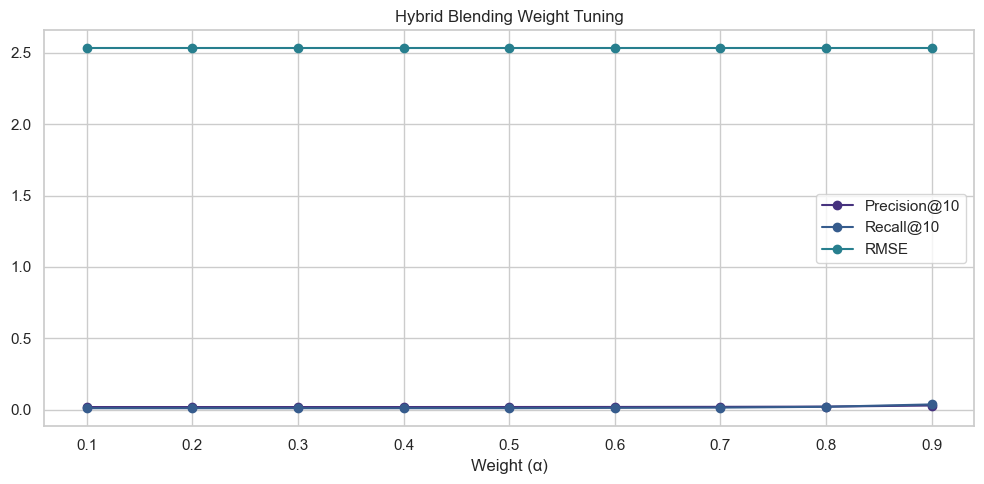

,weight,precision@10,recall@10,rmse
0,0.1,0.017962,0.009981,2.530629
1,0.2,0.017962,0.009981,2.530629
2,0.3,0.017962,0.009981,2.530629
3,0.4,0.017962,0.009981,2.530629
4,0.5,0.018217,0.010022,2.530629
5,0.6,0.018599,0.012116,2.530629
6,0.7,0.019363,0.014039,2.530629
7,0.8,0.021146,0.019644,2.530629
8,0.9,0.028662,0.036385,2.530629


In [13]:
alpha_range = [round(w, 1) for w in np.arange(0.1, 1.0, 0.1)]

tune_hybrid_weights(
    weights=alpha_range,
    model_class=SVDHybridRecommender,
    train_matrix=train_matrix,
    content_sim=content_similarity,
    test_matrix=test_matrix,
    precision_k=10,
    output_path="../data/cleaned/hybrid_tuning_results.csv",
    user_map=user_map,
    item_map=item_map,
    reverse_item_map=reverse_item_map
)